## 1. Imports

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm

print(f"Running on PyMC v{pm.__version__}")

Running on PyMC v5.26.1


## 2. Parameters

## 3. Data

## 4. Model

## 5. Inference

## 6. Results

In [2]:
# %load_ext watermark
az.style.use("arviz-darkgrid")

In [3]:
from scipy.integrate import odeint

# Definition of parameters
a = 1.0
b = 0.1
c = 1.5
d = 0.75

# initial population of rabbits and foxes
X0 = [10.0, 5.0]
# size of data
size = 100
# time lapse
time = 15
t = np.linspace(0, time, size)


# Lotka - Volterra equation
def dX_dt(X, t, a, b, c, d):
    """Return the growth rate of fox and rabbit populations."""

    return np.array([a * X[0] - b * X[0] * X[1], -c * X[1] + d * b * X[0] * X[1]])


# simulator function
def competition_model(rng, a, b, size=None):
    return odeint(dX_dt, y0=X0, t=t, rtol=0.01, args=(a, b, c, d))

In [4]:
def dX_dt(X, t, a, b, c, d):
    # Convert a, b, c, d to float if they are 0-d arrays
    a = float(np.squeeze(a))
    b = float(np.squeeze(b))
    c = float(np.squeeze(c))
    d = float(np.squeeze(d))
    return np.array([a * X[0] - b * X[0] * X[1], -c * X[1] + d * b * X[0] * X[1]])

def competition_model(rng, a, b, size=None):
    # Squeeze parameters so they are scalars
    a = float(np.squeeze(a))
    b = float(np.squeeze(b))
    return odeint(dX_dt, y0=X0, t=t, rtol=0.01, args=(a, b, c, d))

In [5]:
# function for generating noisy data to be used as observed data.
def add_noise(a, b):
    noise = np.random.normal(size=(size, 2))
    simulated = competition_model(None, a, b) + noise
    return simulated
    

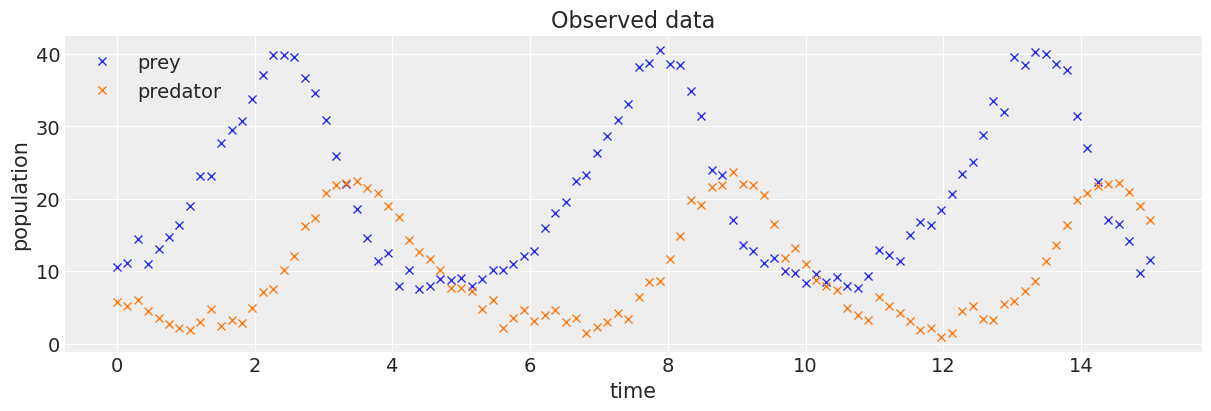

In [6]:
# plotting observed data.
observed = add_noise(a, b)
_, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, observed[:, 0], "x", label="prey")
ax.plot(t, observed[:, 1], "x", label="predator")
ax.set_xlabel("time")
ax.set_ylabel("population")
ax.set_title("Observed data")
ax.legend();

In [10]:
with pm.Model() as model_lv:
    a = pm.HalfNormal("a", 1.0)
    b = pm.HalfNormal("b", 1.0)

    sim = pm.Simulator("sim", competition_model, params=(a, b), epsilon=20, observed=observed)

    idata_lv = pm.sample_smc()

Initializing SMC sampler...
Sampling 8 chains in 8 jobs


Output()

/home/jder/miniconda3/envs/ecosto4/lib/python3.13/site-packages/arviz/data/base.py:272: UserWarning: More chains (8) than draws (6). Passed array should have shape (chains, draws, *shape)
  warnings.warn(


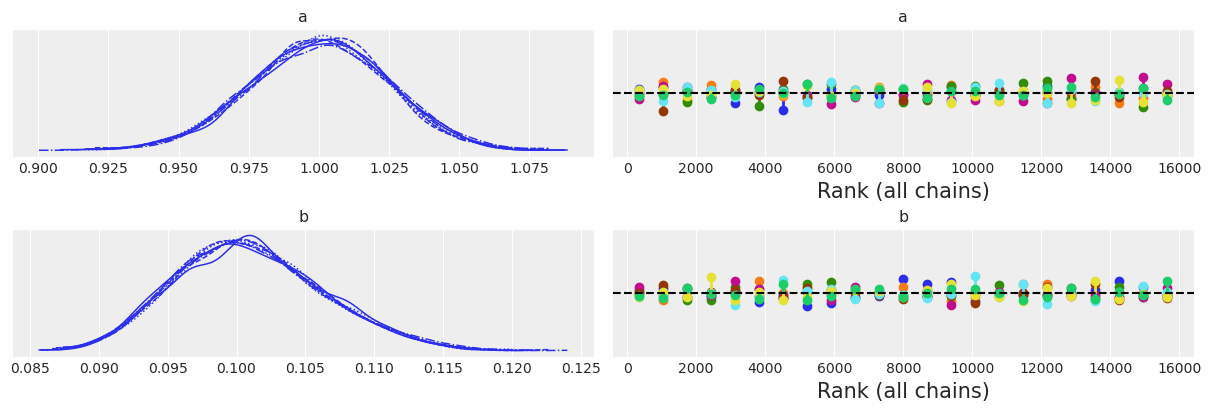

In [11]:
az.plot_trace(idata_lv, kind="rank_vlines");

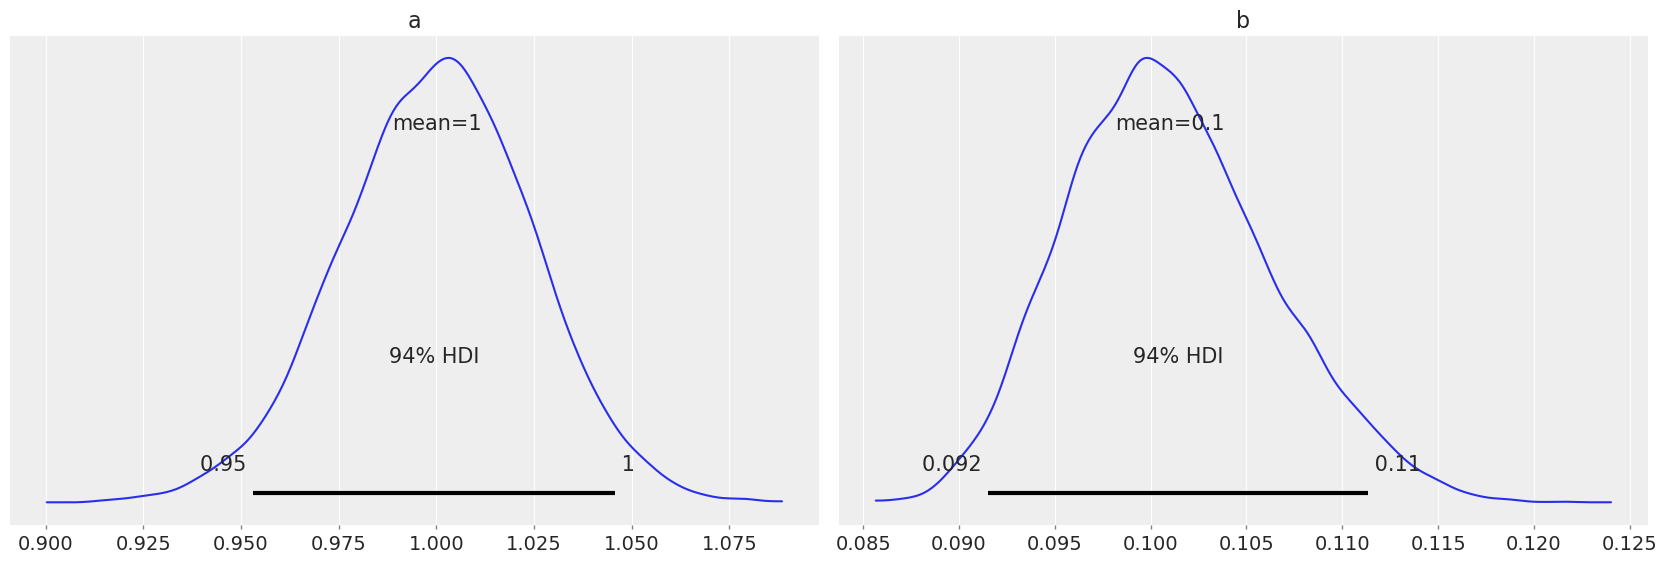

In [12]:
az.plot_posterior(idata_lv);